In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
df.head()


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df["review_content"].isnull().sum()

np.int64(0)

In [5]:
df = df.dropna(subset=["review_content"])

# Sentiment Analysis using Amazon Reviews

The objective of this project is to analyze customer reviews and classify them into Positive, Neutral, and Negative sentiments using Natural Language Processing (NLP).

In [6]:
def get_sentiment(text):

    analysis = TextBlob(str(text))

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity == 0:
        return "Neutral"

    else:
        return "Negative"

In [7]:
df["Sentiment"] = df["review_content"].apply(get_sentiment)

In [8]:
df[["review_content","Sentiment"]].head(10)

,review_content,Sentiment
0,Looks durable Charging is fine tooNo complains...,Positive
1,I ordered this cable to connect my phone to An...,Positive
2,"Not quite durable and sturdy,https://m.media-a...",Positive
3,"Good product,long wire,Charges good,Nice,I bou...",Positive
4,"Bought this instead of original apple, does th...",Positive
5,"It's a good product.,Like,Very good item stron...",Positive
6,Build quality is good and it is comes with 2 y...,Positive
7,Worth for money - suitable for Android auto......,Positive
8,I use this to connect an old PC to internet. I...,Positive
9,I ordered this cable to connect my phone to An...,Positive


In [9]:
df["Sentiment"].value_counts()

Sentiment
Positive    1438
Negative      26
Neutral        1
Name: count, dtype: int64

## Chart 1: Distribution of Customer Sentiments

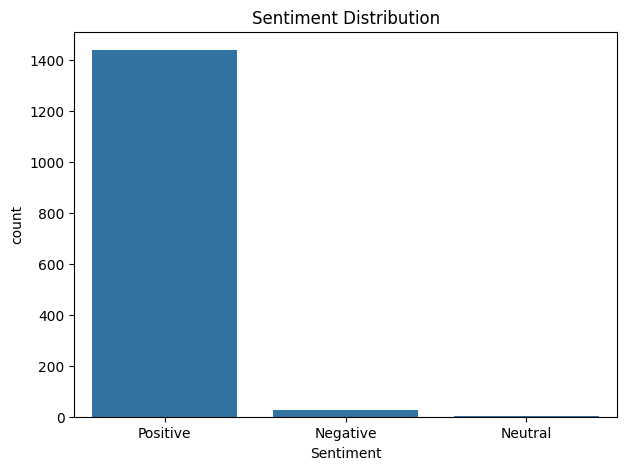

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")

plt.show()

### Observation

- The chart shows the number of Positive, Neutral, and Negative reviews.
- Positive reviews dominate the dataset, indicating high customer satisfaction.
- Negative reviews are comparatively fewer.

## Chart 2: pie chart 

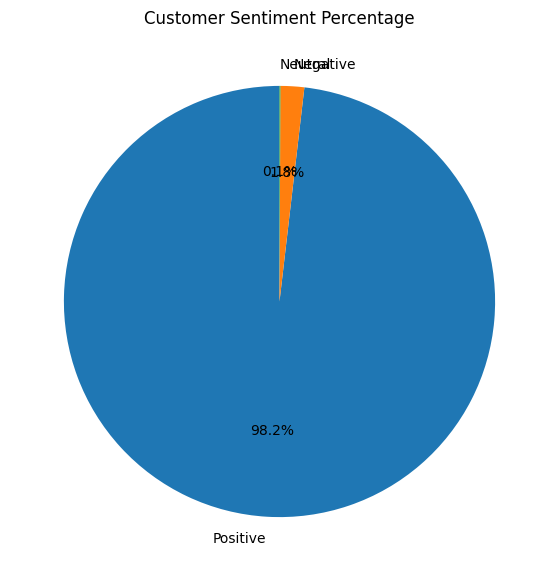

In [11]:
sentiment = df["Sentiment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment,
    labels=sentiment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Sentiment Percentage")

plt.show()

### Observation

- The pie chart illustrates the percentage share of each sentiment category.
- Positive reviews occupy the largest portion of the dataset.
- Neutral and Negative reviews represent a smaller share.

## Chart 3: Word Cloud


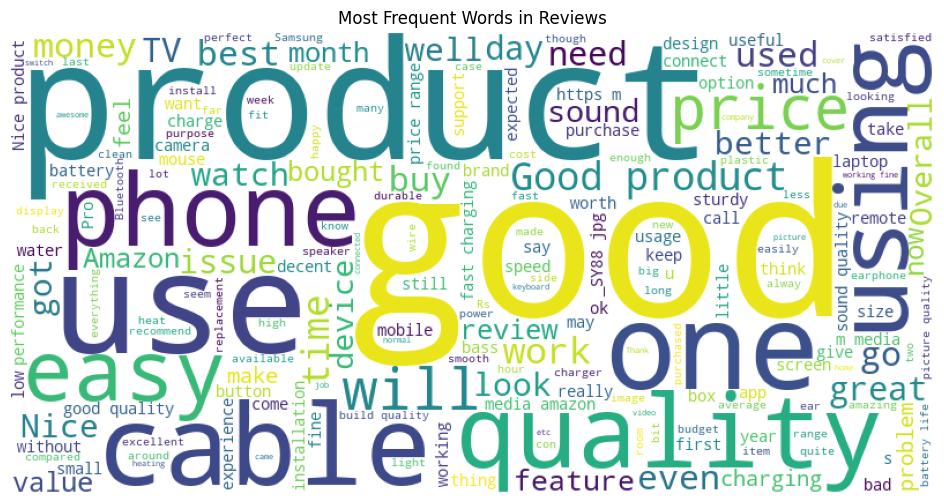

In [12]:
text = " ".join(df["review_content"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Reviews")

plt.show()

### Observation

- The word cloud highlights the most frequently used words in customer reviews.
- Larger words appear more often in the review text.
- It provides a quick overview of common customer opinions.

# Data Story

- The sentiment analysis reveals that most customers express positive opinions about the products.
- The sentiment distribution and pie chart indicate that positive reviews dominate the dataset, reflecting high customer satisfaction. 
- The word cloud highlights frequently mentioned words, providing additional insight into customer feedback. 
- These findings can help businesses understand customer perception and improve products and services.

# Key Insights

- Most reviews are positive.
- Negative reviews are comparatively fewer.
- Customer satisfaction appears to be high.
- Frequently occurring words indicate common product experiences.
- Sentiment analysis helps businesses understand customer opinions and improve decision-making.

# Conclusion

- This project successfully applied Natural Language Processing (NLP) techniques to classify Amazon customer reviews into Positive, Neutral, and Negative sentiments. - The analysis showed that the majority of reviews are positive, indicating favorable customer experiences. 
- Visualizations such as count plots, pie charts, and word clouds provided meaningful insights into customer opinions. 
- These findings can support businesses in improving products, enhancing customer satisfaction, and making data-driven decisions.